# Task 1 EDA: Quark vs Gluon Jet Images

Visualize raw jet images, per-channel distributions, and reconstruction quality.

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import torch

SEED = 42
np.random.seed(SEED)

# Load raw data
with h5py.File('data/quark_jets.h5', 'r') as f:
    quark_images = np.array(f['images'], dtype=np.float32)
with h5py.File('data/gluon_jets.h5', 'r') as f:
    gluon_images = np.array(f['images'], dtype=np.float32)

print(f"Quark: {quark_images.shape}, dtype={quark_images.dtype}")
print(f"Gluon: {gluon_images.shape}, dtype={gluon_images.dtype}")

CHANNEL_NAMES = ["Tracks", "ECAL", "HCAL"]

Quark: (69653, 3, 125, 125), dtype=float32
Gluon: (69653, 3, 125, 125), dtype=float32


## 1. Random Sample: Quark vs Gluon Jet Images (per channel)

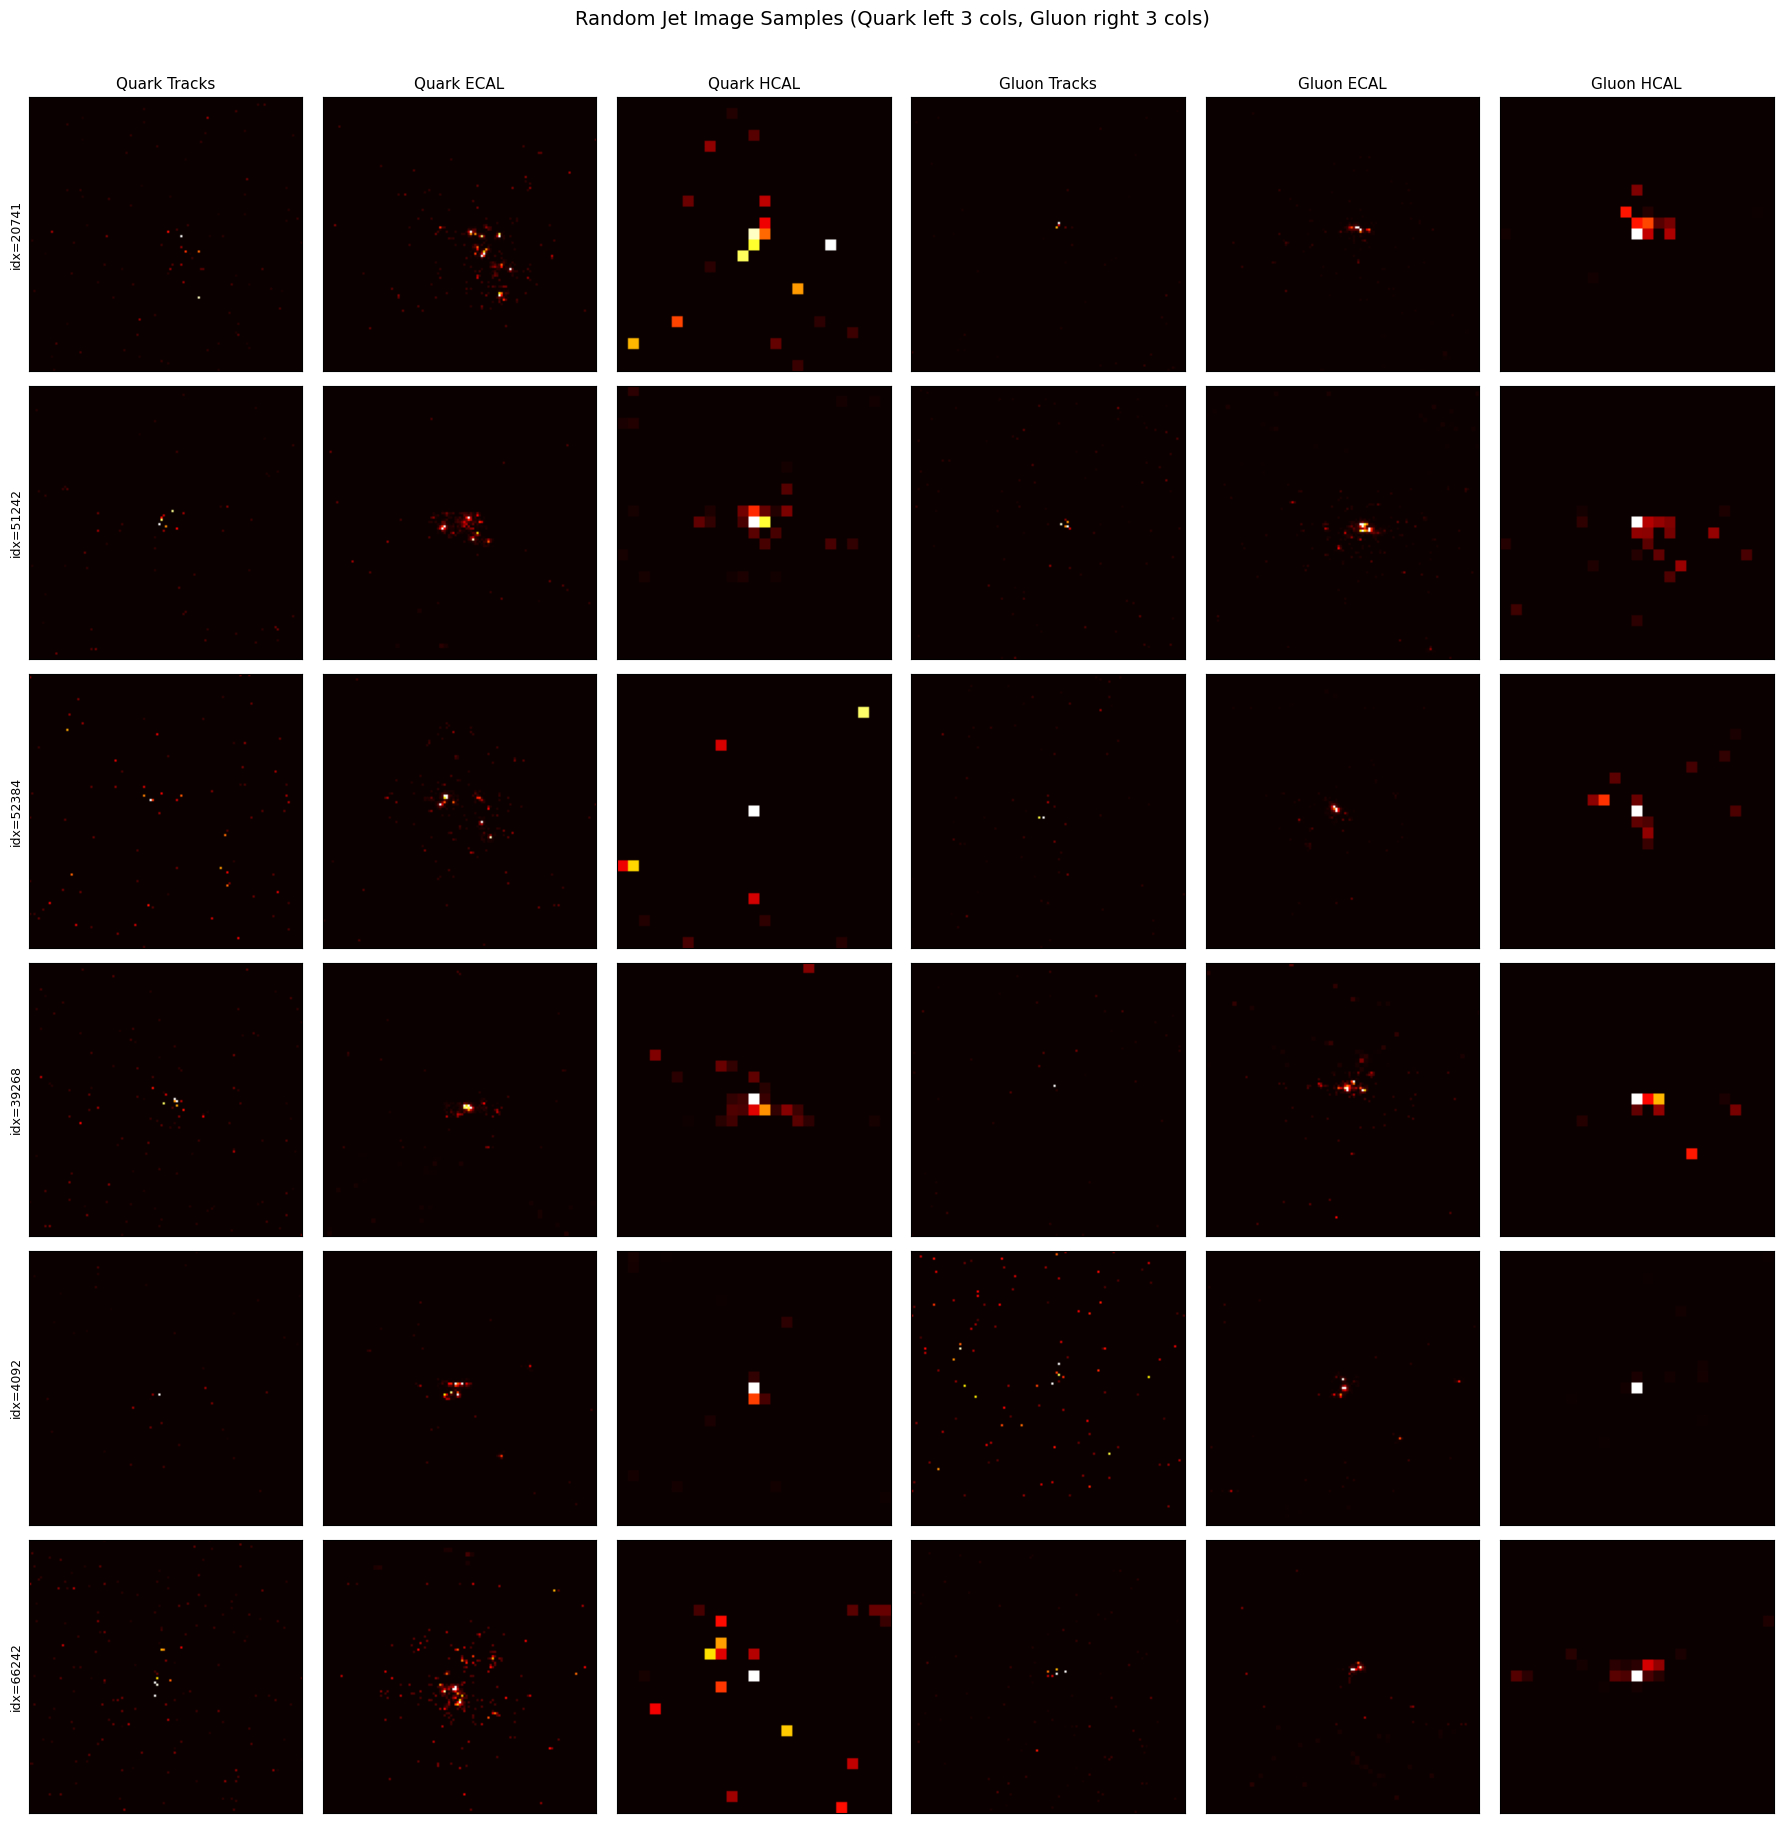

In [2]:
# Sample 6 random jets from each class
rng = np.random.RandomState(SEED)
q_idx = rng.choice(len(quark_images), 6, replace=False)
g_idx = rng.choice(len(gluon_images), 6, replace=False)

fig, axes = plt.subplots(6, 6, figsize=(18, 18))
fig.suptitle("Random Jet Image Samples (Quark left 3 cols, Gluon right 3 cols)", fontsize=14, y=1.01)

for row in range(6):
    # Quark: 3 channels
    for ch in range(3):
        ax = axes[row, ch]
        img = quark_images[q_idx[row], ch]
        vmax = np.percentile(img[img > 0], 99) if np.any(img > 0) else 1
        ax.imshow(img, cmap='hot', vmin=0, vmax=vmax, aspect='equal')
        if row == 0:
            ax.set_title(f"Quark {CHANNEL_NAMES[ch]}", fontsize=11)
        ax.set_xticks([]); ax.set_yticks([])
        if ch == 0:
            ax.set_ylabel(f"idx={q_idx[row]}", fontsize=9)

    # Gluon: 3 channels
    for ch in range(3):
        ax = axes[row, ch + 3]
        img = gluon_images[g_idx[row], ch]
        vmax = np.percentile(img[img > 0], 99) if np.any(img > 0) else 1
        ax.imshow(img, cmap='hot', vmin=0, vmax=vmax, aspect='equal')
        if row == 0:
            ax.set_title(f"Gluon {CHANNEL_NAMES[ch]}", fontsize=11)
        ax.set_xticks([]); ax.set_yticks([])
        if ch == 3:
            ax.set_ylabel(f"idx={g_idx[row]}", fontsize=9)

plt.tight_layout()
plt.show()

## 2. Per-Channel Statistics: Quark vs Gluon

In [3]:
# Per-channel statistics
print(f"{'':>10} {'':>8} {'min':>10} {'max':>10} {'mean':>12} {'nonzero%':>10}")
print("-" * 65)
for label, data in [("Quark", quark_images), ("Gluon", gluon_images)]:
    for ch in range(3):
        ch_data = data[:, ch].ravel()
        nz_frac = np.count_nonzero(ch_data) / ch_data.size * 100
        print(f"{label:>10} {CHANNEL_NAMES[ch]:>8} {ch_data.min():>10.4f} {ch_data.max():>10.4f} {ch_data.mean():>12.6f} {nz_frac:>9.2f}%")

                           min        max         mean   nonzero%
-----------------------------------------------------------------
     Quark   Tracks     0.0000   756.5963     0.000081      0.53%
     Quark     ECAL     0.0000     4.1044     0.000049      1.74%
     Quark     HCAL     0.0000     0.4314     0.000029      2.82%
     Gluon   Tracks     0.0000   307.1599     0.000079      0.47%
     Gluon     ECAL     0.0000     9.3341     0.000053      1.41%
     Gluon     HCAL     0.0000     0.4328     0.000033      2.56%


## 3. Nonzero Pixel Value Distributions (per channel)

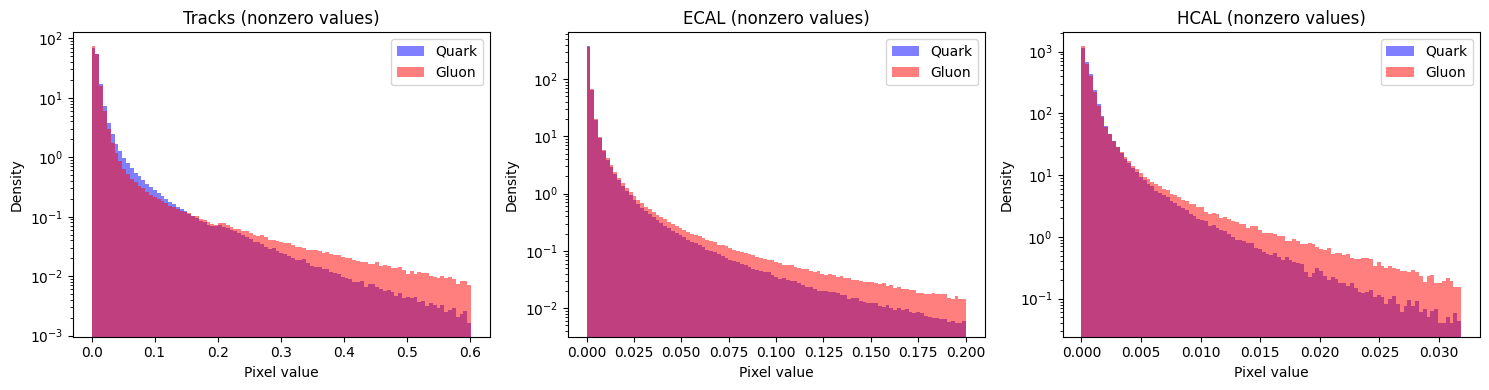

In [4]:
# Distribution of nonzero pixel values per channel
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ch in range(3):
    ax = axes[ch]
    q_nz = quark_images[:, ch].ravel()
    q_nz = q_nz[q_nz > 0]
    g_nz = gluon_images[:, ch].ravel()
    g_nz = g_nz[g_nz > 0]
    
    clip = np.percentile(np.concatenate([q_nz, g_nz]), 99.9)
    bins = np.linspace(0, clip, 100)
    
    ax.hist(q_nz, bins=bins, alpha=0.5, label='Quark', density=True, color='blue')
    ax.hist(g_nz, bins=bins, alpha=0.5, label='Gluon', density=True, color='red')
    ax.set_title(f"{CHANNEL_NAMES[ch]} (nonzero values)")
    ax.set_xlabel("Pixel value")
    ax.set_ylabel("Density")
    ax.legend()
    ax.set_yscale('log')

plt.tight_layout()
plt.show()

## 4. Sparsity & Energy: Per-image nonzero pixel count and total energy

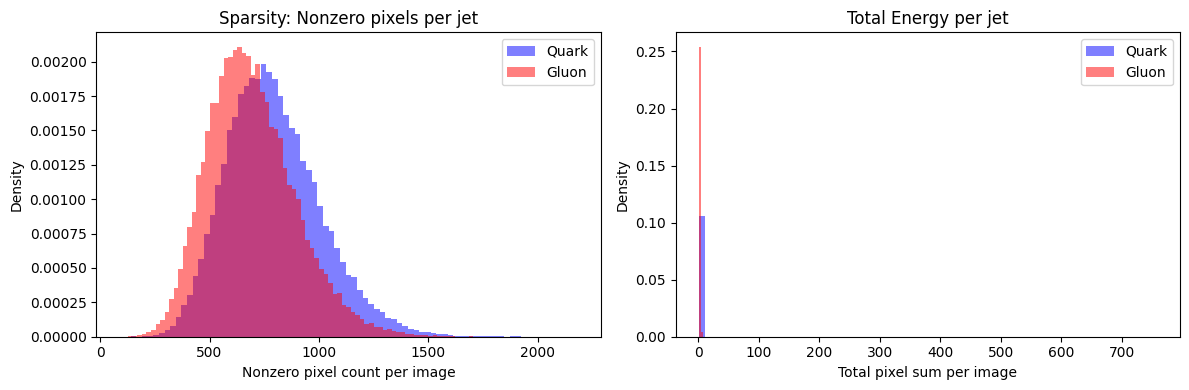

Quark nonzero pixels: mean=794, median=773
Gluon nonzero pixels: mean=693, median=674


In [5]:
# Per-image: number of nonzero pixels and total energy
q_nnz = np.count_nonzero(quark_images.reshape(len(quark_images), -1), axis=1)
g_nnz = np.count_nonzero(gluon_images.reshape(len(gluon_images), -1), axis=1)
q_energy = quark_images.reshape(len(quark_images), -1).sum(axis=1)
g_energy = gluon_images.reshape(len(gluon_images), -1).sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(q_nnz, bins=80, alpha=0.5, label='Quark', density=True, color='blue')
axes[0].hist(g_nnz, bins=80, alpha=0.5, label='Gluon', density=True, color='red')
axes[0].set_xlabel("Nonzero pixel count per image")
axes[0].set_ylabel("Density")
axes[0].set_title("Sparsity: Nonzero pixels per jet")
axes[0].legend()

axes[1].hist(q_energy, bins=80, alpha=0.5, label='Quark', density=True, color='blue')
axes[1].hist(g_energy, bins=80, alpha=0.5, label='Gluon', density=True, color='red')
axes[1].set_xlabel("Total pixel sum per image")
axes[1].set_ylabel("Density")
axes[1].set_title("Total Energy per jet")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Quark nonzero pixels: mean={q_nnz.mean():.0f}, median={np.median(q_nnz):.0f}")
print(f"Gluon nonzero pixels: mean={g_nnz.mean():.0f}, median={np.median(g_nnz):.0f}")

## 5. Average Jet Image: Quark vs Gluon

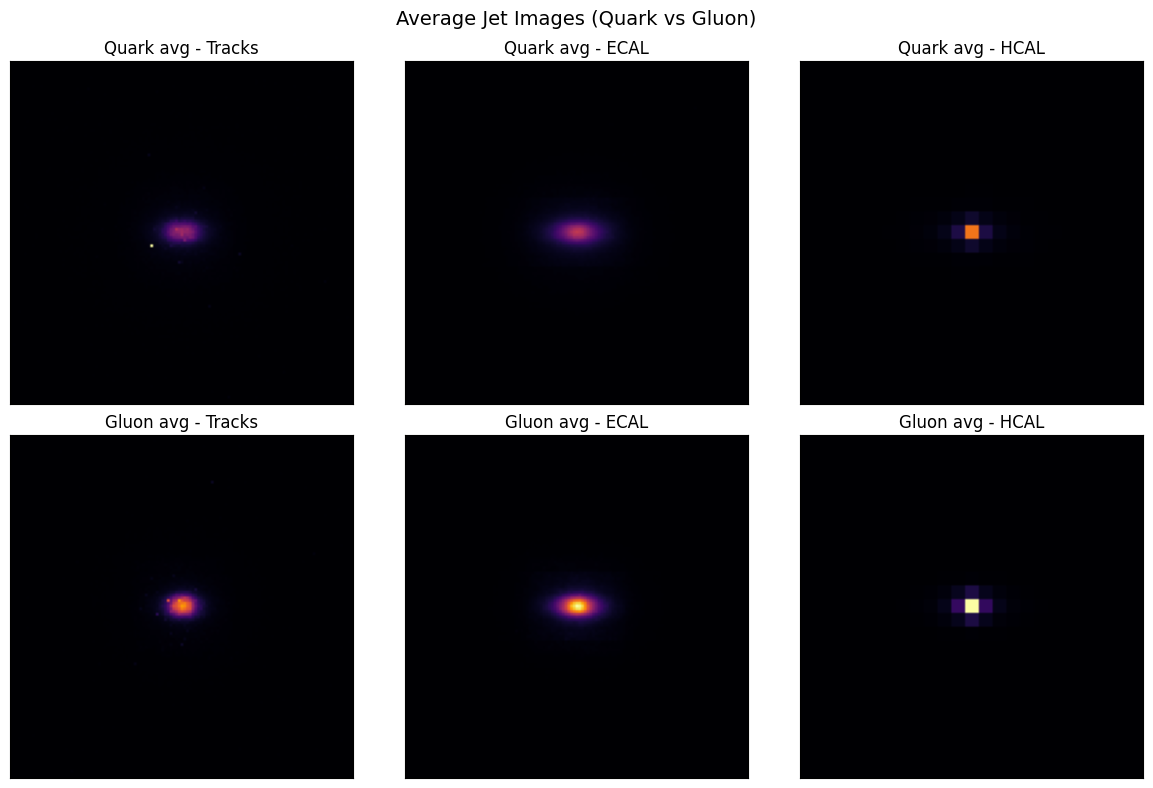

In [6]:
# Average jet images
q_avg = quark_images.mean(axis=0)
g_avg = gluon_images.mean(axis=0)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ch in range(3):
    vmax = max(q_avg[ch].max(), g_avg[ch].max())
    axes[0, ch].imshow(q_avg[ch], cmap='inferno', vmin=0, vmax=vmax)
    axes[0, ch].set_title(f"Quark avg - {CHANNEL_NAMES[ch]}")
    axes[0, ch].set_xticks([]); axes[0, ch].set_yticks([])
    
    axes[1, ch].imshow(g_avg[ch], cmap='inferno', vmin=0, vmax=vmax)
    axes[1, ch].set_title(f"Gluon avg - {CHANNEL_NAMES[ch]}")
    axes[1, ch].set_xticks([]); axes[1, ch].set_yticks([])

plt.suptitle("Average Jet Images (Quark vs Gluon)", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Reconstruction Quality (if trained model available)

Loaded normalization stats from data\norm_stats.npy
  Tracks: clip at 0.448129
  ECAL: clip at 0.140687
  HCAL: clip at 0.023506
Loaded model from epoch 25, val_loss=0.000027


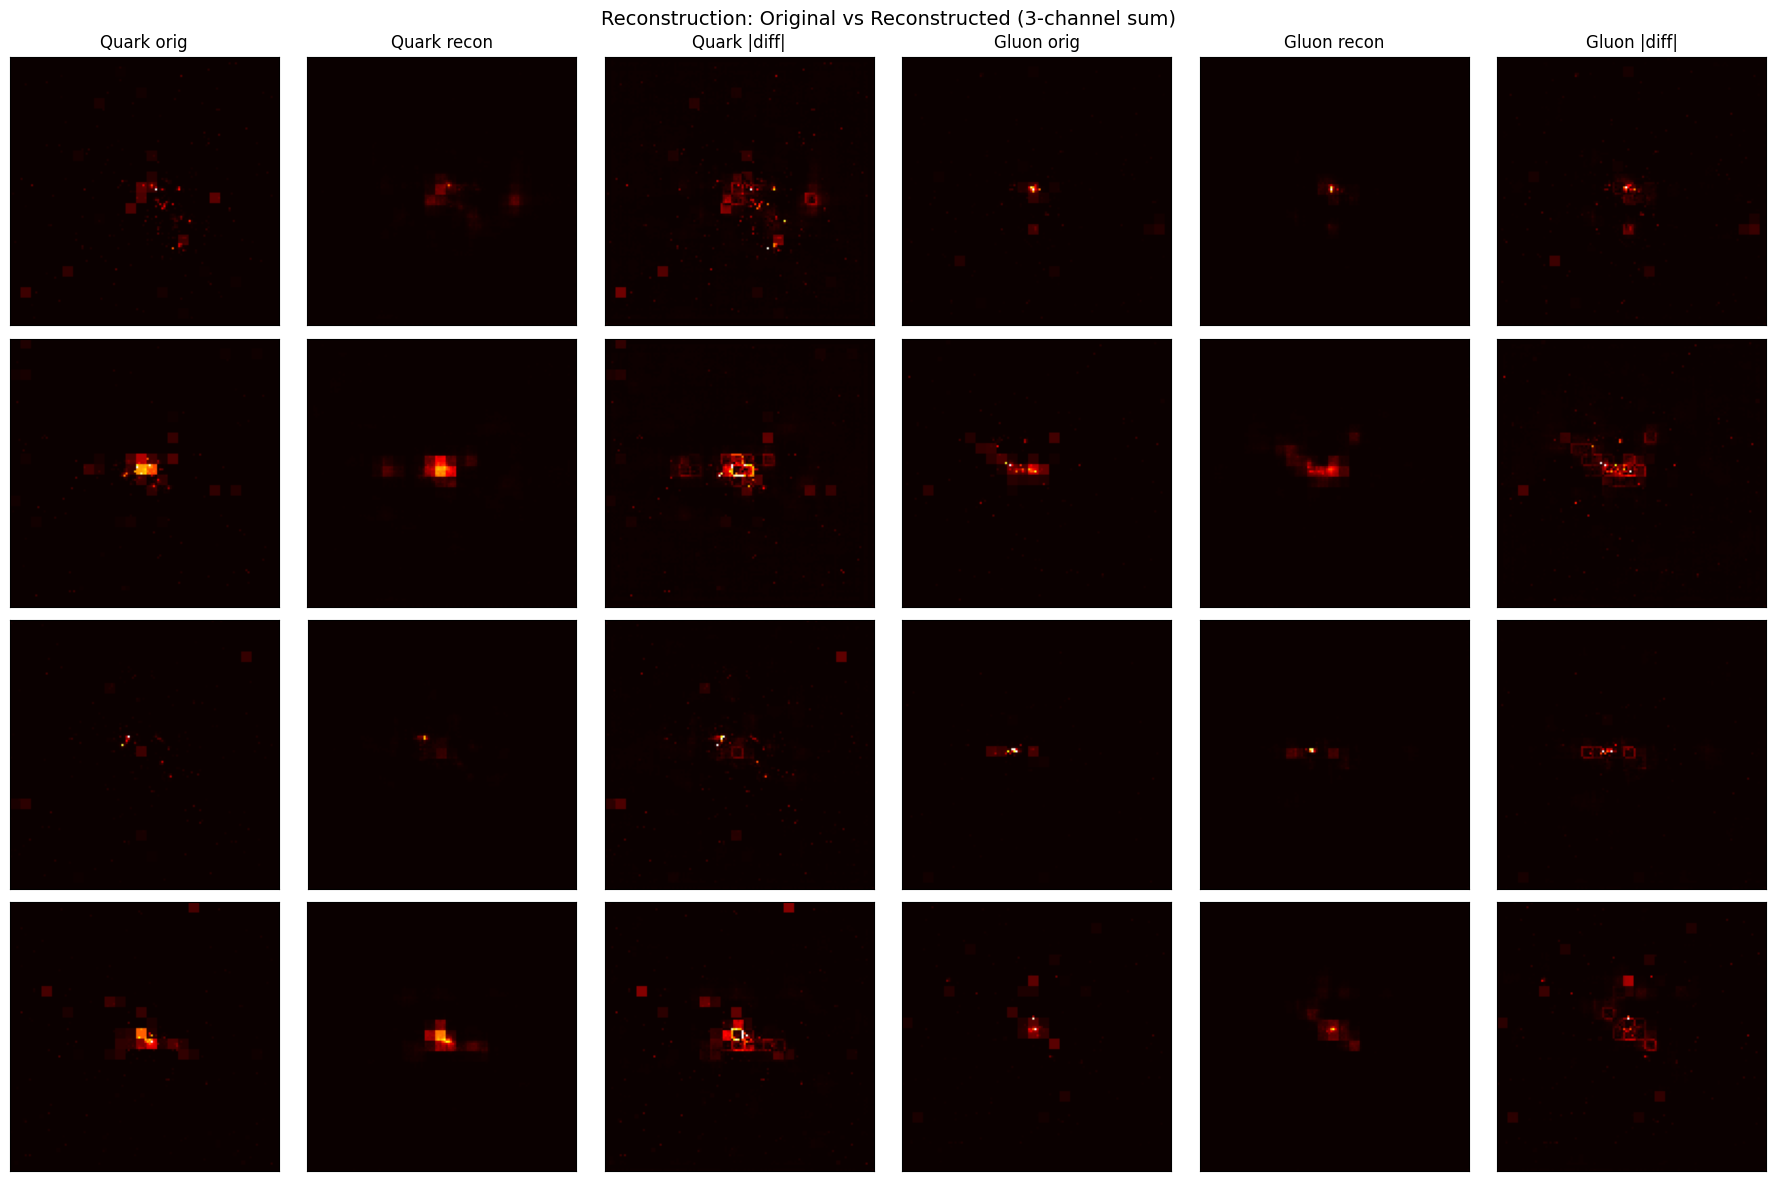

In [9]:
from pathlib import Path
import sys
sys.path.insert(0, '.')
from models import ConvAutoencoder
from data import load_or_compute_norm_stats
import config

model_path = Path(config.CHECKPOINT_DIR) / f"{config.MODEL_NAME}_best.pt"
if model_path.exists():
    clip_vals = load_or_compute_norm_stats(config.QUARK_DATA_FILE)
    
    model = ConvAutoencoder()
    ckpt = torch.load(model_path, map_location='cpu')
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    print(f"Loaded model from epoch {ckpt['epoch']+1}, val_loss={ckpt['val_loss']:.6f}")
    
    # Reuse already-loaded data: normalize and pad inline
    def normalize_and_pad(raw_img, clip_vals):
        """Normalize a raw (3,125,125) image and zero-pad to (3,128,128)."""
        img = raw_img.copy()
        for ch in range(3):
            img[ch] = np.clip(img[ch], 0, clip_vals[ch]) / clip_vals[ch]
        padded = np.zeros((3, 128, 128), dtype=np.float32)
        padded[:, :125, :125] = img
        return torch.from_numpy(padded)
    
    # Sample and reconstruct
    rng2 = np.random.RandomState(SEED)
    sample_idx = rng2.choice(min(len(quark_images), len(gluon_images)), 4, replace=False)
    
    fig, axes = plt.subplots(4, 6, figsize=(18, 12))
    fig.suptitle("Reconstruction: Original vs Reconstructed (3-channel sum)", fontsize=14)
    
    for row, idx in enumerate(sample_idx):
        # Quark
        q_img = normalize_and_pad(quark_images[idx], clip_vals).unsqueeze(0)
        with torch.no_grad():
            q_rec = model(q_img)
        q_orig = q_img[0].sum(dim=0).numpy()
        q_recon = q_rec[0].sum(dim=0).numpy()
        q_diff = np.abs(q_orig - q_recon)
        
        vmax = max(q_orig.max(), q_recon.max())
        axes[row, 0].imshow(q_orig, cmap='hot', vmin=0, vmax=vmax)
        axes[row, 0].set_title("Quark orig" if row == 0 else "")
        axes[row, 1].imshow(q_recon, cmap='hot', vmin=0, vmax=vmax)
        axes[row, 1].set_title("Quark recon" if row == 0 else "")
        axes[row, 2].imshow(q_diff, cmap='hot', vmin=0, vmax=vmax * 0.5)
        axes[row, 2].set_title("Quark |diff|" if row == 0 else "")
        
        # Gluon
        g_img = normalize_and_pad(gluon_images[idx], clip_vals).unsqueeze(0)
        with torch.no_grad():
            g_rec = model(g_img)
        g_orig = g_img[0].sum(dim=0).numpy()
        g_recon = g_rec[0].sum(dim=0).numpy()
        g_diff = np.abs(g_orig - g_recon)
        
        vmax = max(g_orig.max(), g_recon.max())
        axes[row, 3].imshow(g_orig, cmap='hot', vmin=0, vmax=vmax)
        axes[row, 3].set_title("Gluon orig" if row == 0 else "")
        axes[row, 4].imshow(g_recon, cmap='hot', vmin=0, vmax=vmax)
        axes[row, 4].set_title("Gluon recon" if row == 0 else "")
        axes[row, 5].imshow(g_diff, cmap='hot', vmin=0, vmax=vmax * 0.5)
        axes[row, 5].set_title("Gluon |diff|" if row == 0 else "")
    
    for ax in axes.ravel():
        ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    plt.show()
else:
    print(f"No model checkpoint found at {model_path}. Train first with: python train.py")